# 04- Model training

## Objectif
Entraîner et comparer Régression Logistique, Random Forest, SVC et XGBoost

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from xgboost import XGBClassifier

df = pd.read_csv("../01_Data/processed/churn_features.csv")

if "customerID" in df.columns:
    df = df.drop(columns=["customerID"])

X = df.drop(columns=["Churn"])
y = df["Churn"]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [2]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced", n_jobs=-1),
    "SVC": SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
}

results = []
fitted_models = {}

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    fitted_models[name] = pipeline

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results).sort_values("f1_score", ascending=False)
results_df

,model,accuracy,precision,recall,f1_score,roc_auc
2,SVC,0.750887,0.520282,0.788770,0.626993,0.822151
0,Logistic Regression,0.741661,0.508711,0.780749,0.616034,0.847754
3,XGBoost,0.803407,0.657980,0.540107,0.593245,0.841025
1,Random Forest,0.782115,0.612795,0.486631,0.542474,0.824121


## Interprétation
Les quatre modèles sont comparés avec les mêmes données et les mêmes métriques.
Pour le churn, le recall et le F1-score sont prioritaires.


Meilleur modèle : SVC
              precision    recall  f1-score   support

           0       0.91      0.74      0.81      1035
           1       0.52      0.79      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



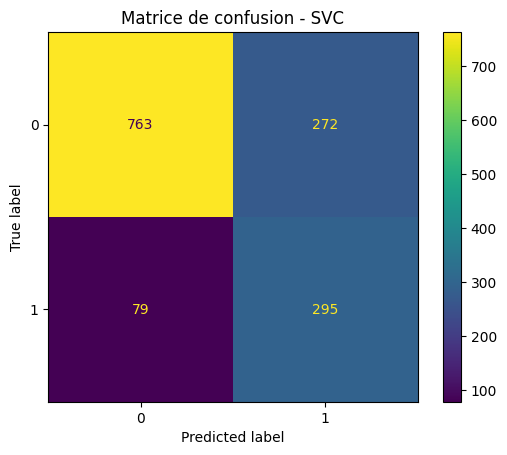

In [3]:
best_model_name = results_df.iloc[0]["model"]
best_model = fitted_models[best_model_name]

print("Meilleur modèle :", best_model_name)
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"Matrice de confusion - {best_model_name}")
plt.show()

In [4]:
results_df.to_csv("../04_Models/model_comparison_results.csv", index=False)
print("Comparaison des modèles sauvegardée.")

Comparaison des modèles sauvegardée.
